In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Synthetic time series (noisy sine)
t = np.linspace(0, 20*np.pi, 600)
data = np.sin(t) + np.random.normal(0, 0.05, size=t.size)

# 2. Task: predict next value from current value
X = data[:-1]   # input  (value now)
Y = data[1:]    # target (value next step)

In [2]:
X

array([ 0.0018675 ,  0.13287465,  0.18743197,  0.30623584,  0.41008946,
        0.42965544,  0.58234514,  0.62433437,  0.74465564,  0.81332706,
        0.84603207,  1.00706684,  0.87991213,  0.98542379,  0.98132019,
        1.10880662,  0.98469585,  0.95709663,  0.94553062,  0.90795719,
        0.84362608,  0.81881308,  0.69743639,  0.6141555 ,  0.57613876,
        0.4996334 ,  0.44842194,  0.31089725,  0.19908897,  0.07875064,
       -0.00126043, -0.03562378, -0.18178756, -0.2581771 , -0.36084043,
       -0.4439917 , -0.50741665, -0.7009273 , -0.76857801, -0.90731434,
       -0.84323573, -0.9594109 , -0.90466631, -0.94972143, -0.99260863,
       -1.00177276, -0.9758877 , -0.91728177, -0.96100629, -0.94115883,
       -0.83131437, -0.74099023, -0.80147358, -0.62618402, -0.53602294,
       -0.45073147, -0.33541512, -0.28173366, -0.15331613, -0.05571416,
       -0.03595868,  0.11867715,  0.20807939,  0.3136653 ,  0.33171534,
        0.47987637,  0.60184122,  0.61164106,  0.63620874,  0.85

In [3]:
Y

array([ 0.13287465,  0.18743197,  0.30623584,  0.41008946,  0.42965544,
        0.58234514,  0.62433437,  0.74465564,  0.81332706,  0.84603207,
        1.00706684,  0.87991213,  0.98542379,  0.98132019,  1.10880662,
        0.98469585,  0.95709663,  0.94553062,  0.90795719,  0.84362608,
        0.81881308,  0.69743639,  0.6141555 ,  0.57613876,  0.4996334 ,
        0.44842194,  0.31089725,  0.19908897,  0.07875064, -0.00126043,
       -0.03562378, -0.18178756, -0.2581771 , -0.36084043, -0.4439917 ,
       -0.50741665, -0.7009273 , -0.76857801, -0.90731434, -0.84323573,
       -0.9594109 , -0.90466631, -0.94972143, -0.99260863, -1.00177276,
       -0.9758877 , -0.91728177, -0.96100629, -0.94115883, -0.83131437,
       -0.74099023, -0.80147358, -0.62618402, -0.53602294, -0.45073147,
       -0.33541512, -0.28173366, -0.15331613, -0.05571416, -0.03595868,
        0.11867715,  0.20807939,  0.3136653 ,  0.33171534,  0.47987637,
        0.60184122,  0.61164106,  0.63620874,  0.85358543,  0.84

In [4]:
# 3. Build the reservoir
np.random.seed(0)
N = 100                                   # number of reservoir nodes
W_in = np.random.randn(N, 1) * 0.5        # input weights (fixed)
W_res = np.random.randn(N, N) * 0.1       # recurrent weights (fixed)

# spectral radius scaling (keeps activity stable)
eigs = np.max(np.abs(np.linalg.eigvals(W_res)))
W_res = W_res / eigs * 0.9                # set spectral radius to 0.9


In [5]:
# 4. Run the input through the reservoir, collect states
states = np.zeros((len(X), N))
x = np.zeros((N, 1))
for i in range(len(X)):
    u = X[i].reshape(1, 1)
    x = np.tanh(W_in @ u + W_res @ x)     # reservoir update
    states[i] = x.flatten()

# 5. Train readout (plain linear regression for now)
from numpy.linalg import lstsq
W_out, *_ = lstsq(states, Y, rcond=None)  # learn readout weights


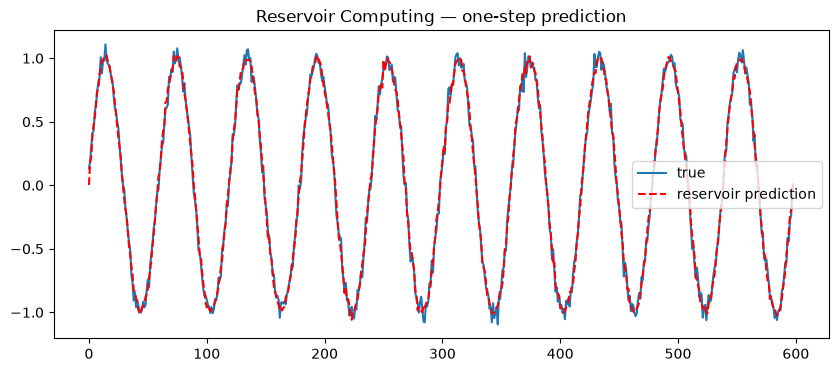

MSE: 0.002604500897167612


In [6]:
# 6. Predict and plot
pred = states @ W_out

plt.figure(figsize=(10,4))
plt.plot(Y, label="true")
plt.plot(pred, "r--", label="reservoir prediction")
plt.legend(); plt.title("Reservoir Computing — one-step prediction")
plt.show()

print("MSE:", np.mean((Y - pred)**2))